In [11]:
pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 222.6 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 405.7 kB/s eta 0:00:00
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/8.3 MB ? eta -:--:--
    --------------------------------------- 0.1/8.3 MB 1.7 MB/s eta 0:00:05
   - -------------------------------------- 0.3/8.3 MB 2.0 MB/s eta 0:00:05
   -- ------------------------------------- 0.4/8.3 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.3 MB 2.3 MB/s eta 0:00:04
   --- -----------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB 1.4 MB/s eta 0:01:14
   ---------------------------------------- 0.0/100.2 MB 495.5 kB/s eta 0:03:23
   ---------------------------------------- 0.1/100.2 MB 660.6 kB/s eta 0:02:32
   ---------------------------------------- 0.1/100.2 MB 853.3 kB/s eta 0:01:58
   ---------------------------------------- 0.2/100.2 MB 1.1 MB/s eta 0:01:35
   ---------------------------------------- 0.3/100.2 MB 1.3 MB/s eta 0:01:17
   ---------------------------------------- 0.4/100.2 MB 1.3 MB/s eta 0:01:15
   ---------------------------------------- 0.4/100.2 MB 1.3 MB/s eta 0:01:15
   ---------------------------------------- 0.5/100.2 MB 1.2 MB/s eta 0:01:25
   -----


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 660.6 kB/s eta 0:02:34
   ---------------------------------------- 0.0/101.7 MB 660.6 kB/s eta 0:02:34
   ---------------------------------------- 0.1/101.7 MB 409.6 kB/s eta 0:04:09
   ---------------------------------------- 0.1/101.7 MB 602.4 kB/s eta 0:02:49
   ---------------------------------------- 0.2/101.7 MB 831.5 kB/s eta 0:02:03
   ---------------------------------------- 0.3/101.7 MB 1.0 MB/s eta 0:01:38
   ----------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#Basic import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [17]:
df = pd.read_csv(r"C:\Users\HP\Desktop\ML_Project\notebook\data\Stud.csv")

In [20]:
x = df.drop(columns=['math score'])

In [21]:
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [22]:
print("Categories in 'gender' variable : ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable : ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable : ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable : ", end=" ")
print(df['lunch'].unique())

Categories in 'gender' variable :  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable :  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable :  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable :  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str


In [23]:
y = df['math score']

In [24]:
#create column transformer with 3 types of transformers
num_features = x.select_dtypes(exclude="object").columns
cat_features = x.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

C:\Users\HP\AppData\Local\Temp\ipykernel_27608\354909463.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include="object").columns


In [27]:
x = preprocessor.fit_transform(x)

In [28]:
x.shape

(1000, 19)

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((800, 19), (200, 19))

In [30]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [33]:
models = {
    "LinearRegression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "KNeighborsRegressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "RandomForestRegressor" : RandomForestRegressor(),
    "XGBRegressor" : XGBRegressor(),
    "CatBoosting Regressor" : CatBoostRegressor(verbose=False),
    "AdaBoostRegressor" : AdaBoostRegressor()
}
model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train,y_train)
    
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error : {:.4f}".format(model_train_mae))
    print("- R2 Score : {:.4f}".format(model_train_r2))
    
    print('-------------------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error : {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error : {:.4f}".format(model_test_mae))
    print("- R2 Score : {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')
    

LinearRegression
Model performance for Training set
- Root Mean Squared Error : 5.3231
- Mean Absolute Error : 4.2667
- R2 Score : 0.8743
-------------------------------------------
Model performance for Test set
- Root Mean Squared Error : 5.3940
- Mean Absolute Error : 4.2148
- R2 Score : 0.8804


Lasso
Model performance for Training set
- Root Mean Squared Error : 6.5938
- Mean Absolute Error : 5.2063
- R2 Score : 0.8071
-------------------------------------------
Model performance for Test set
- Root Mean Squared Error : 6.5197
- Mean Absolute Error : 5.1579
- R2 Score : 0.8253


Ridge
Model performance for Training set
- Root Mean Squared Error : 5.3233
- Mean Absolute Error : 4.2650
- R2 Score : 0.8743
-------------------------------------------
Model performance for Test set
- Root Mean Squared Error : 5.3904
- Mean Absolute Error : 4.2111
- R2 Score : 0.8806


KNeighborsRegressor
Model performance for Training set
- Root Mean Squared Error : 5.7077
- Mean Absolute Error : 4.516

Text(0, 0.5, 'Predicted')

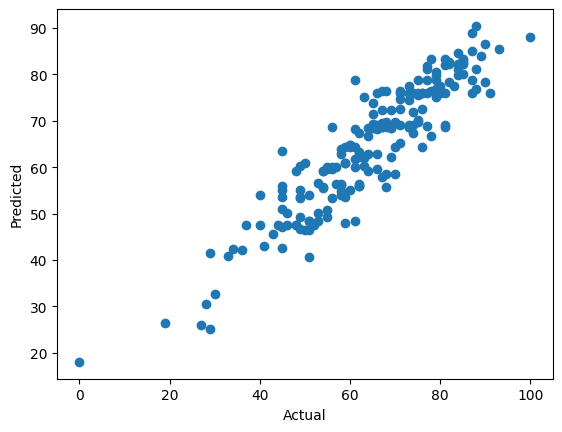

In [34]:
plt.scatter(y_test,y_test_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math score'>

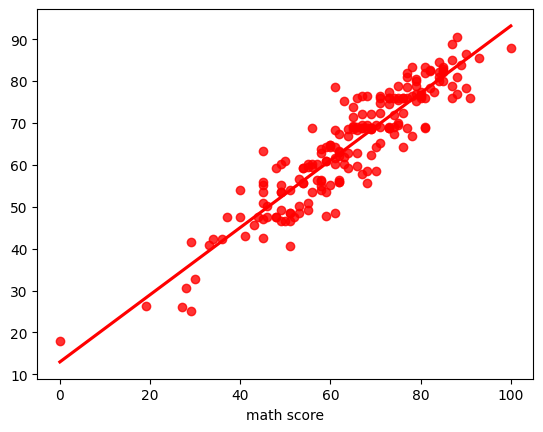

In [40]:
sns.regplot(x=y_test,y=y_test_pred,ci=None,color='red')

In [41]:
#Difference between actual and predicted values
pred_df = pd.DataFrame({'Actual value' : y_test,'Predicted Value' : y_test_pred,'Difference':y_test-y_test_pred})
pred_df

,Actual value,Predicted Value,Difference
521,91,75.981273,15.018727
737,53,56.618321,-3.618321
740,80,76.441176,3.558824
660,74,76.042373,-2.042373
411,84,82.180000,1.820000
...,...,...,...
408,52,47.518519,4.481481
332,62,56.469565,5.530435
208,74,67.414773,6.585227
613,65,68.519481,-3.519481
